## Cellpose-SAM: superhuman generalization for cellular segmentation

Marius Pachitariu, Michael Rariden, Carsen Stringer

[paper](https://www.biorxiv.org/content/10.1101/2025.04.28.651001v1) | [code](https://github.com/MouseLand/cellpose)

This notebook shows how to process your own 2D or 3D images, saved on Google Drive.

This notebook is adapted from the notebook by Pradeep Rajasekhar, inspired by the [ZeroCostDL4Mic notebook series](https://github.com/HenriquesLab/ZeroCostDL4Mic/wiki).

### Make sure you have GPU access enabled by going to Runtime -> Change Runtime Type -> Hardware accelerator and selecting GPU

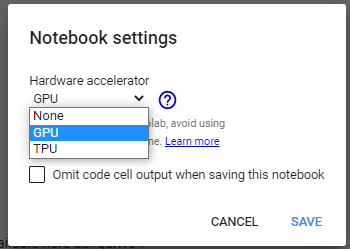

### Mount your google drive

Run this cell to connect your Google Drive to colab:
* Click on the URL.
* Sign in your Google Account.

You will either have to:
* copy the authorisation code and enter it into box below OR
* in the new google colab, you can just click "Allow" and it should connect.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive



Then click on "Folder" icon on the Left, press the refresh button. Your Google Drive folder should now be available here as "gdrive".


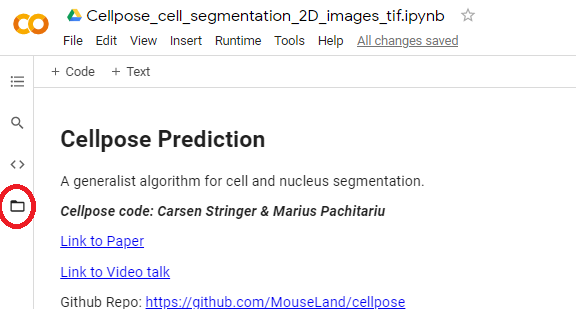

Click on the triangle icon and it will allow you to access whole drive. Navigate to the folder containing your images. Once you are there, click on the three dots on the right of the folder and select "Copy Path"

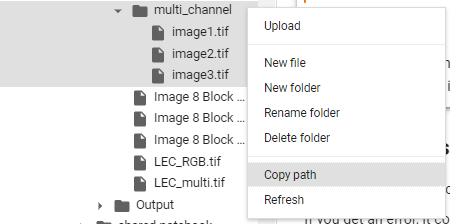

Copy and paste this path in the **dir** string below

### Install Cellpose-SAM


In [3]:
!pip install git+https://www.github.com/mouseland/cellpose.git

  Cloning https://www.github.com/mouseland/cellpose.git to /tmp/pip-req-build-3q9fxdci
  Running command git clone --filter=blob:none --quiet https://www.github.com/mouseland/cellpose.git /tmp/pip-req-build-3q9fxdci
  Resolved https://www.github.com/mouseland/cellpose.git to commit 17fb25f40055ec2636aa708dc4cf6625b8b4735d
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 94.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 83.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 98.8 MB/s eta 0:00:00
  Created wheel for cellpose: filename=cellpose-4.0.8-py3-none-any.whl size=212051 sha256=c7c1c010556c6344c831469f695646dee99a308fee61fd32f0ad0dd31f6194fe
  Stored in directory: /tmp/pip-ephem-wheel-cache-myjlrl5c/wheels/df/b6/31/a3013c44290eabb46f4c06d1efb19744124fcad2d59684ec5e
Successfully built cellpose


Check GPU and instantiate model - will download weights.

In [4]:
import numpy as np
from cellpose import models, core, io, plot
from pathlib import Path
from tqdm import trange
import matplotlib.pyplot as plt
from natsort import natsorted

io.logger_setup() # run this to get printing of progress

#Check if colab notebook instance has GPU access
if core.use_gpu()==False:
  raise ImportError("No GPU access, change your runtime")

model = models.CellposeModel(gpu=True)

creating new log file
2025-12-13 01:31:16,147 [INFO] WRITING LOG OUTPUT TO /root/.cellpose/run.log
2025-12-13 01:31:16,148 [INFO] 
cellpose version: 	4.0.8 
platform:       	linux 
python version: 	3.12.12 
torch version:  	2.9.0+cu126
2025-12-13 01:31:16,379 [INFO] ** TORCH CUDA version installed and working. **
2025-12-13 01:31:16,381 [INFO] ** TORCH CUDA version installed and working. **
2025-12-13 01:31:16,383 [INFO] >>>> using GPU (CUDA)
2025-12-13 01:31:20,078 [INFO] Downloading: "https://huggingface.co/mouseland/cellpose-sam/resolve/main/cpsam" to /root/.cellpose/models/cpsam



100%|██████████| 1.15G/1.15G [00:07<00:00, 173MB/s]


Input directory with your images:

In [ ]:
# *** change to your google drive folder path ***
dir = "/content/sample_data/img"
dir = Path(dir)
if not dir.exists():
  raise FileNotFoundError("directory does not exist")

# *** change to your image extension ***
image_ext = ".tiff"

# list all files
files = natsorted([f for f in dir.glob("*"+image_ext) if "_masks" not in f.name and "_flows" not in f.name])

if(len(files)==0):
  raise FileNotFoundError("no image files found, did you specify the correct folder and extension?")
else:
  print(f"{len(files)} images in folder:")

for f in files:
  print(f.name)

3023 images in folder:
0.tiff
1.tiff
2.tiff
3.tiff
4.tiff
5.tiff
6.tiff
7.tiff
8.tiff
9.tiff
10.tiff
11.tiff
12.tiff
13.tiff
14.tiff
15.tiff
16.tiff
17.tiff
18.tiff
19.tiff
20.tiff
21.tiff
22.tiff
23.tiff
24.tiff
25.tiff
26.tiff
27.tiff
28.tiff
29.tiff
30.tiff
31.tiff
32.tiff
33.tiff
34.tiff
35.tiff
36.tiff
37.tiff
38.tiff
39.tiff
40.tiff
41.tiff
42.tiff
43.tiff
44.tiff
45.tiff
46.tiff
47.tiff
48.tiff
49.tiff
50.tiff
51.tiff
52.tiff
53.tiff
54.tiff
55.tiff
56.tiff
57.tiff
58.tiff
59.tiff
60.tiff
61.tiff
62.tiff
63.tiff
64.tiff
65.tiff
66.tiff
67.tiff
68.tiff
69.tiff
70.tiff
71.tiff
72.tiff
73.tiff
74.tiff
75.tiff
76.tiff
77.tiff
78.tiff
79.tiff
80.tiff
81.tiff
82.tiff
83.tiff
84.tiff
85.tiff
86.tiff
87.tiff
88.tiff
89.tiff
90.tiff
91.tiff
92.tiff
93.tiff
94.tiff
95.tiff
96.tiff
97.tiff
98.tiff
99.tiff
100.tiff
101.tiff
102.tiff
103.tiff
104.tiff
105.tiff
106.tiff
107.tiff
108.tiff
109.tiff
110.tiff
111.tiff
112.tiff
113.tiff
114.tiff
115.tiff
116.tiff
117.tiff
118.tiff
119.tiff
120.tif

## Run Cellpose-SAM on one image in folder

Here are some of the parameters you can change:

* ***flow_threshold*** is  the  maximum  allowed  error  of  the  flows  for  each  mask.   The  default  is 0.4.
    *  **Increase** this threshold if cellpose is not returning as many masks as you’d expect (or turn off completely with 0.0)
    *   **Decrease** this threshold if cellpose is returning too many ill-shaped masks.

* ***cellprob_threshold*** determines proability that a detected object is a cell.   The  default  is 0.0.
    *   **Decrease** this threshold if cellpose is not returning as many masks as you’d expect or if masks are too small
    *   **Increase** this threshold if cellpose is returning too many masks esp from dull/dim areas.

* ***tile_norm_blocksize*** determines the size of blocks used for normalizing the image. The default is 0, which means the entire image is normalized together.
  You may want to change this to 100-200 pixels if you have very inhomogeneous brightness across your image.



In [ ]:
img = io.imread(files[0])

print(f'your image has shape: {img.shape}. Assuming channel dimension is last with {img.shape[-1]} channels')

your image has shape: (1200, 1600). Assuming channel dimension is last with 1600 channels


### Channel Selection:

- Use the dropdowns below to select the _zero-indexed_ channels of your image to segment. The order does not matter. Remember to rerun the cell after you edit the dropdowns.

- If you have a histological image taken in brightfield, you don't need to adjust the channels.

- If you have a fluroescent image with multiple stains, you should choose one channel with a cytoplasm/membrane stain, one channel with a nuclear stain, and set the third channel to `None`. Choosing multiple channels may produce segmentaiton of all the structures in the image. If you have retrained the model on your data with a thrid stain (described below), you can run segmentation with all channels.

In [ ]:
first_channel = '0' # @param ['None', 0, 1, 2, 3, 4, 5]
second_channel = '1' # @param ['None', 0, 1, 2, 3, 4, 5]
third_channel = 'None' # @param ['None', 0, 1, 2, 3, 4, 5]

In [ ]:
selected_channels = []
for i, c in enumerate([first_channel, second_channel, third_channel]):
  if c == 'None':
    continue
  if int(c) > img.shape[-1]:
    assert False, 'invalid channel index, must have index greater or equal to the number of channels'
  if c != 'None':
    selected_channels.append(int(c))

if img.ndim == 2:
  img_selected_channels = img[:, :, None]     # make it H × W × 1
else:
  img_selected_channels = np.zeros_like(img)
  img_selected_channels[:, :, :len(selected_channels)] = img[:, :, selected_channels]


# flow_threshold = 0.9
# cellprob_threshold = -1
# tile_norm_blocksize = 0
# channels={"nucleus":0}

# masks, flows, styles = model.eval(channels, batch_size=32, flow_threshold=flow_threshold, cellprob_threshold=cellprob_threshold,
#                                   normalize={"tile_norm_blocksize": tile_norm_blocksize}, diameter=20)

masks, flows, styles = model.eval(img_selected_channels, batch_size=32, flow_threshold=flow_threshold, cellprob_threshold=cellprob_threshold,
                                  normalize={"tile_norm_blocksize": tile_norm_blocksize}, diameter=20)

fig = plt.figure(figsize=(12,5))
plot.show_segmentation(fig, channels, masks, flows[0])
plt.tight_layout()
plt.show()


AttributeError: 'dict' object has no attribute 'squeeze'

## Run Cellpose-SAM on folder of images

if you have many large images, you may want to run them as a loop over images



In [ ]:
a=[]

masks_ext = ".png" if image_ext == ".png" else ".tif"
for i in trange(len(files)):
    f = files[i]
    img = io.imread(f)
    masks, flows, styles = model.eval(img, batch_size=32, flow_threshold=flow_threshold, cellprob_threshold=cellprob_threshold,
                                  normalize={"tile_norm_blocksize": tile_norm_blocksize})
    io.imsave(dir / (f.stem + "_masks" + masks_ext), masks)

    # count cells
    cell_count = len(np.unique(masks)) - 1

    a.append(cell_count)

In [ ]:
b=[]

from pathlib import Path
import pandas as pd
import numpy as np

path = r'/content/sample_data/ground'  # or unix / linux / mac path
# Get the files from the path provided in the OP
files = natsorted([f for f in Path(path).glob('*.csv')])  # .rglob to get subdirectories

for f in files:
  df = pd.read_csv(f)
  rows, columns = df.shape
  print(f"Rows: {rows}, Columns: {columns}")
  b.append(rows)

2025-12-01 18:31:21,187 [INFO] NumExpr defaulting to 2 threads.
Rows: 65, Columns: 2
Rows: 97, Columns: 2
Rows: 135, Columns: 2
Rows: 90, Columns: 2
Rows: 51, Columns: 2
Rows: 2, Columns: 2
Rows: 2, Columns: 2
Rows: 46, Columns: 2
Rows: 73, Columns: 2
Rows: 56, Columns: 2
Rows: 1, Columns: 2
Rows: 3, Columns: 2
Rows: 125, Columns: 2
Rows: 4, Columns: 2
Rows: 86, Columns: 2
Rows: 113, Columns: 2
Rows: 119, Columns: 2
Rows: 97, Columns: 2
Rows: 73, Columns: 2
Rows: 2, Columns: 2
Rows: 54, Columns: 2
Rows: 7, Columns: 2
Rows: 89, Columns: 2
Rows: 2, Columns: 2
Rows: 7, Columns: 2
Rows: 91, Columns: 2
Rows: 104, Columns: 2
Rows: 206, Columns: 2
Rows: 4, Columns: 2
Rows: 27, Columns: 2
Rows: 106, Columns: 2
Rows: 6, Columns: 2
Rows: 26, Columns: 2
Rows: 91, Columns: 2
Rows: 23, Columns: 2
Rows: 46, Columns: 2
Rows: 17, Columns: 2
Rows: 20, Columns: 2
Rows: 42, Columns: 2
Rows: 52, Columns: 2
Rows: 25, Columns: 2
Rows: 128, Columns: 2
Rows: 204, Columns: 2
Rows: 113, Columns: 2
Rows: 15, Col

In [2]:
# c=[]
# # print(len(a))
# # print(len(b))

# if len(a) != len(b):
#   raise FileNotFoundError("amount of images processed are not the same are images that have ground truth")
# else:
#   i = 0
#   while i < len(a):
#     if b[i] == 0:
#       if a[i] == 0:
#         c.append(1)
#       else:
#         c.append(-1*a[i])
#     else:
#       c.append(round(abs((b[i]-a[i])/b[i]),2))
#     i+=1

# print(c)
import numpy as np

def compute_metrics(preds: np.ndarray, labels: np.ndarray, eps: float = 1e-8):
    # preds, labels: 1-D arrays of total counts per image (floats)
    # Returns dict: mae, mse, rmse, mape (percent), acp (percent within 5%).
    assert preds.shape == labels.shape
    err = preds - labels
    abs_err = np.abs(err)
    mae = float(np.mean(abs_err))
    mse = float(np.mean(err ** 2))
    rmse = float(np.sqrt(mse))
    denom = np.maximum(np.abs(labels), eps)
    mape = float(np.mean((abs_err / denom))) * 100.0
    # ACP: accept if relative error <= 5% (handle label==0 with small absolute tolerance)
    rel_ok = np.zeros_like(labels, dtype=bool)
    mask_nonzero = np.abs(labels) > eps
    rel_ok[mask_nonzero] = (abs_err[mask_nonzero] / np.abs(labels[mask_nonzero])) <= 0.05
    rel_ok[~mask_nonzero] = (abs_err[~mask_nonzero] <= 0.05)
    acp = float(rel_ok.mean() * 100.0)
    return {'mae': mae, 'mse': mse, 'rmse': rmse, 'mape': mape, 'acp': acp}

In [ ]:
compute_metrics(a,b)

In [ ]:
!zip -r /content/sample_data/img.zip /content/sample_data/img
from google.colab import files
files.download("/content/sample_data/img.zip")

  adding: content/sample_data/img/ (stored 0%)
  adding: content/sample_data/img/1106.tiff (deflated 74%)
  adding: content/sample_data/img/1490.tiff (deflated 82%)
  adding: content/sample_data/img/1182_masks.tif (deflated 92%)
  adding: content/sample_data/img/1250_masks.tif (deflated 57%)
  adding: content/sample_data/img/1008.tiff (deflated 76%)
  adding: content/sample_data/img/1941_masks.tif (deflated 29%)
  adding: content/sample_data/img/1354.tiff (deflated 82%)
  adding: content/sample_data/img/1601_masks.tif (deflated 75%)
  adding: content/sample_data/img/1266.tiff (deflated 64%)
  adding: content/sample_data/img/1429.tiff (deflated 87%)
  adding: content/sample_data/img/1499.tiff (deflated 76%)
  adding: content/sample_data/img/1709_masks.tif (deflated 8%)
  adding: content/sample_data/img/1825_masks.tif (deflated 29%)
  adding: content/sample_data/img/1606.tiff (deflated 77%)
  adding: content/sample_data/img/1955_masks.tif (deflated 40%)
  adding: content/sample_data/img/

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

if you have small images, you may want to load all of them first and then run, so that they can be batched together on the GPU

In [ ]:
print("loading images")
imgs = [io.imread(files[i]) for i in trange(len(files))]

print("running cellpose-SAM")
masks, flows, styles = model.eval(imgs, batch_size=32, flow_threshold=flow_threshold, cellprob_threshold=cellprob_threshold,
                                  normalize={"tile_norm_blocksize": tile_norm_blocksize})

print("saving masks")
for i in trange(len(files)):
    f = files[i]
    io.imsave(dir / (f.stem + "_masks" + masks_ext), masks[i])

loading images


100%|██████████| 3023/3023 [00:40<00:00, 74.03it/s] 

running cellpose-SAM
2025-11-30 08:27:48,099 [INFO] 0%|          | 0/3023 [00:00<?, ?it/s]


2025-11-30 08:28:04,727 [INFO] No cell pixels found.
2025-11-30 08:29:09,198 [INFO] 0%|          | 4/3023 [01:21<14:36:23, 17.42s/it]
2025-11-30 08:29:13,905 [INFO] No cell pixels found.
2025-11-30 08:31:59,214 [INFO] 0%|          | 14/3023 [04:11<14:05:12, 16.85s/it]
2025-11-30 08:32:01,880 [INFO] No cell pixels found.
2025-11-30 08:32:29,217 [INFO] 1%|          | 16/3023 [04:41<14:02:31, 16.81s/it]
2025-11-30 08:32:35,238 [INFO] No cell pixels found.
2025-11-30 08:33:09,222 [INFO] 1%|          | 18/3023 [05:21<14:01:05, 16.79s/it]
2025-11-30 08:33:25,593 [INFO] No cell pixels found.
2025-11-30 08:33:39,224 [INFO] 1%|          | 20/3023 [05:51<13:59:29, 16.77s/it]
2025-11-30 08:33:59,277 [WARNING] no seeds found in get_masks_torch - no masks found.
2025-11-30 08:34:19,227 [INFO] 1%|          | 22/3023 [06:31<14:00:05, 16.80s/it]
2025-11-30 08:34:32,631 [INFO] No cell pixels found.
2025-11-30 08:36:29,244 [INFO] 1%|          | 30/3023 [08:41<13:58:01, 16.80s/it]
2025-11-30 08:36:47,221

to save your masks for ImageJ, run the following code:

In [ ]:
for i in trange(len(files)):
    f = files[i]
    masks0 = io.imsave(dir / (f.name + "_masks" + masks_ext))
    io.save_rois(masks0, f)